# 01 — Feature sanity checks

**Visual sanity only — no feature logic lives in notebooks.** Everything shown
here is read from the Phase 2 artifacts (`data/processed/features_*.parquet`
and their manifests), which are produced by `python -m src.features.build_features`.

Three checks on the daily timeframe:

1. close price with a few context/volatility features overlaid,
2. candlestick pattern fire rates,
3. correlation heatmap of the technical features.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
raw = pd.read_parquet(ROOT / "data/raw/btc_usdt_1d.parquet")
features = pd.read_parquet(ROOT / "data/processed/features_1d.parquet")
manifest = json.loads((ROOT / "data/processed/features_1d.manifest.json").read_text())

df = raw[["open_time", "close"]].merge(features, on="open_time", validate="one_to_one")
print(f"raw: {raw.shape}, features: {features.shape}, merged: {df.shape}")
print(f"features built at {manifest['built_at_utc']} from {manifest['source']['parquet']}")

raw: (2415, 11), features: (2415, 60), merged: (2415, 61)
features built at 2026-08-12T00:58:44+00:00 from data/raw/btc_usdt_1d.parquet


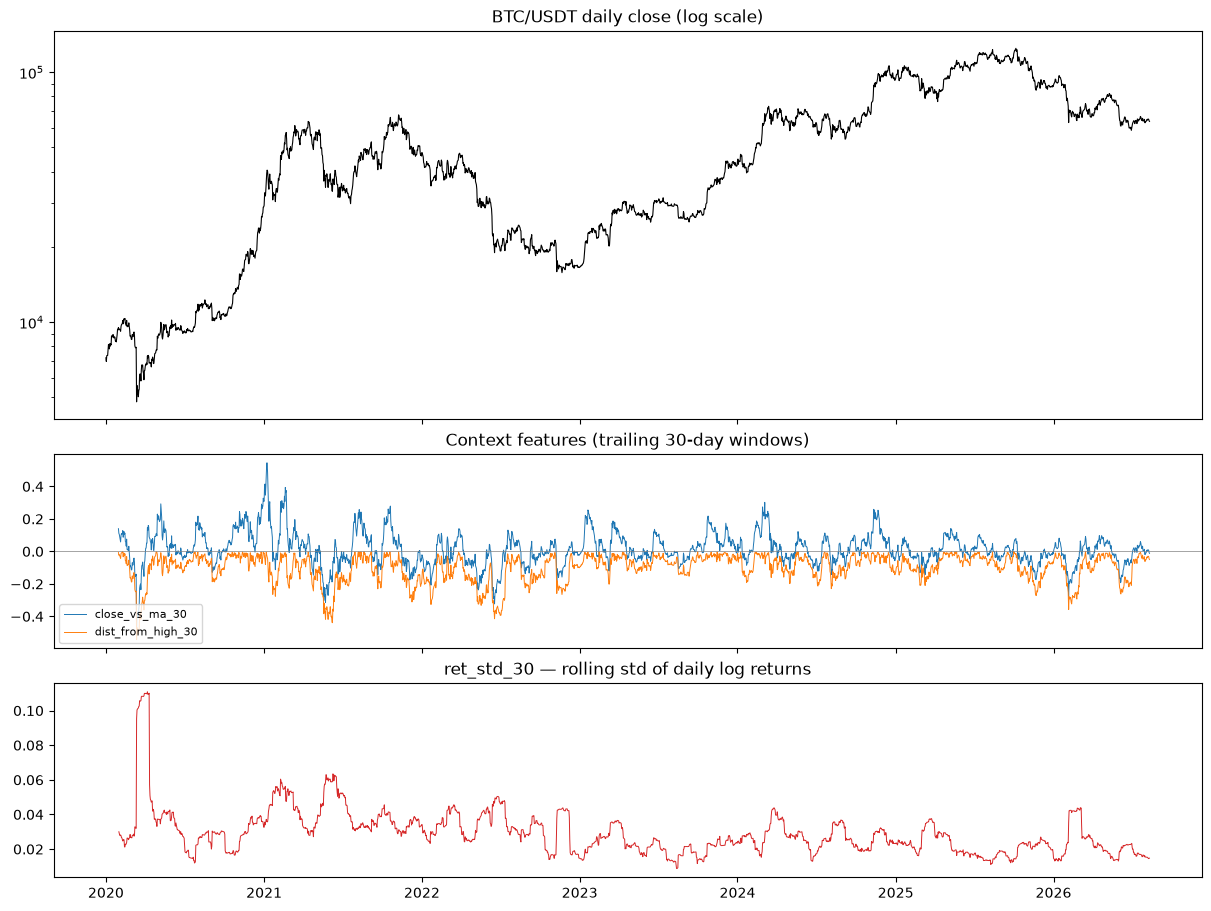

In [2]:
fig, axes = plt.subplots(
    3, 1, figsize=(12, 9), sharex=True, height_ratios=[2, 1, 1], constrained_layout=True
)
axes[0].plot(df["open_time"], df["close"], lw=0.8, color="black")
axes[0].set_yscale("log")
axes[0].set_title("BTC/USDT daily close (log scale)")

axes[1].plot(df["open_time"], df["close_vs_ma_30"], lw=0.7, label="close_vs_ma_30")
axes[1].plot(df["open_time"], df["dist_from_high_30"], lw=0.7, label="dist_from_high_30")
axes[1].axhline(0.0, color="grey", lw=0.5)
axes[1].set_title("Context features (trailing 30-day windows)")
axes[1].legend(loc="lower left", fontsize=8)

axes[2].plot(df["open_time"], df["ret_std_30"], lw=0.7, color="tab:red")
axes[2].set_title("ret_std_30 — rolling std of daily log returns")
plt.show()

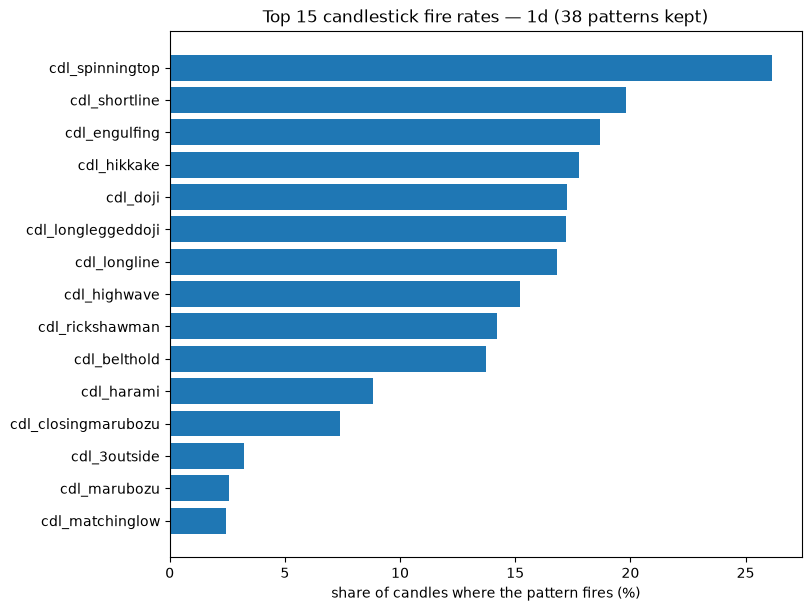

In [3]:
cdl_cols = manifest["features"]["candlestick"]
rates = features[cdl_cols].ne(0).mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.barh(rates.index[::-1], 100 * rates.values[::-1], color="tab:blue")
ax.set_xlabel("share of candles where the pattern fires (%)")
ax.set_title(f"Top 15 candlestick fire rates — 1d ({len(cdl_cols)} patterns kept)")
plt.show()

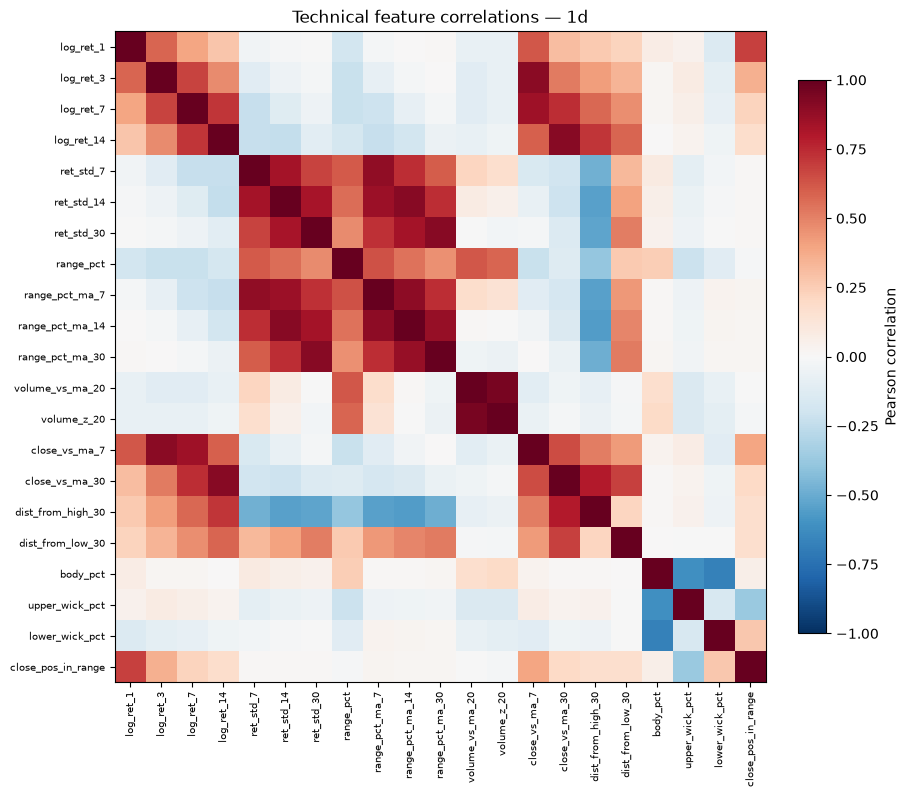

In [4]:
tech_cols = manifest["features"]["technical"]
corr = features[tech_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(tech_cols)), tech_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(tech_cols)), tech_cols, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Technical feature correlations — 1d")
plt.show()